In [1]:
# Clone repository
!git clone https://YOUR_PERSONAL_ACCESS_TOKEN@github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers.git

# Enter repository
%cd MNIST-ML-ImageClassifiers

# Configure Git identity
!git config --global user.name "loaymahmoud10"
!git config --global user.email "lorarri911@gmail.com"

# Update local main
!git checkout main
!git pull origin main

# Create and switch to Phase 2 branch
!git checkout -b multinomialLR

fatal: destination path 'MNIST-ML-ImageClassifiers' already exists and is not an empty directory.
/content/MNIST-ML-ImageClassifiers
M	MNIST-ML-ImageClassifiers
Switched to branch 'main'
Your branch is up to date with 'origin/main'.
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 33 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (33/33), 8.85 KiB | 603.00 KiB/s, done.
From https://github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers
 * branch            main       -> FETCH_HEAD
   5d9a3cd..624cba1  main       -> origin/main
Updating 5d9a3cd..624cba1
Fast-forward
 results/phase2/kernel_svm_hog_confusion_matrix.png | Bin 192397 -> 0 bytes
 results/phase2/kernel_svm_hog_loss_curves.png      | Bin 498051 -> 0 bytes
 results/phase2/kernel_svm_pca_confusion_matrix.png | Bin 205403 -> 0 bytes
 results/phase2/kernel_svm_pca_loss_curves.png      | Bin 404658 -> 0

In [2]:
import os

print(os.listdir("results"))
print("\nPhase 2 contents:")
print(os.listdir("results/phase2"))

['logreg_flatten_tuning_confusion_matrix.png', 'nb_feature_comparison_table.txt', 'svm_loss_curves.png', 'nb_pca_results.png', 'logreg_lambda_tuning.json', 'logreg_flatten_tuning.json', 'svm_results.csv', 'logreg_threshold_0.6_confusion_matrix.png', 'logreg_baseline_model.json', 'decision_tree_hog_confusion_matrix.png', 'logreg_threshold_0.4_confusion_matrix.png', 'nb_cross_validation_results.txt', 'decision_tree_results.txt', 'logreg_threshold_0.7_confusion_matrix.png', 'decision_tree_comparison.png', '.gitkeep', 'logreg_pca50_tuning.json', 'logreg_hog_tuning.json', 'decision_tree_pca_confusion_matrix.png', 'logreg_threshold_tuning.json', 'logreg_PCA50_tuning_confusion_matrix.png', 'nb_hog_results.png', 'phase2', 'logreg_HOG_tuning_confusion_matrix.png', 'svm_confusion_matrices.png', 'nb_flatten_results.png', 'decision_tree_flatten_confusion_matrix.png', 'logreg_threshold_0.5_confusion_matrix.png', 'logreg_baseline__confusion_matrix.png']

Phase 2 contents:
['linear_svm_hog_learning_c

# Model

In [3]:
%%writefile models/multinomial_logistic_regression.py
import numpy as np


class MultinomialLogisticRegression:

    def __init__(self, lr=0.01, epochs=1000, lambda_=0.01):

        self.lr = lr
        self.epochs = epochs
        self.lambda_ = lambda_

        self.W = None
        self.b = None

        self.loss_history = []
        self.val_loss_history = []

        self.train_acc_history = []
        self.val_acc_history = []

    def softmax(self, z):

        z = z - np.max(z, axis=1, keepdims=True)

        exp_z = np.exp(z)

        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def one_hot(self, y, n_classes):

        one_hot_y = np.zeros((len(y), n_classes))

        one_hot_y[np.arange(len(y)), y] = 1

        return one_hot_y

    def compute_loss(self, y_true, y_pred, n_samples):

        cross_entropy = -np.sum(y_true * np.log(y_pred + 1e-15)) / n_samples

        l2_term = (self.lambda_ / (2 * n_samples)) * np.sum(self.W ** 2)

        return cross_entropy + l2_term

    def accuracy(self, y_true, y_pred):

        return np.mean(y_true == y_pred)

    def fit(self, X, y, X_val=None, y_val=None):

        n_samples, n_features = X.shape

        n_classes = len(np.unique(y))

        self.W = np.zeros((n_features, n_classes))
        self.b = np.zeros((1, n_classes))

        y_one_hot = self.one_hot(y, n_classes)

        for epoch in range(self.epochs):

            # Forward pass
            scores = np.dot(X, self.W) + self.b

            probs = self.softmax(scores)

            # Training loss
            train_loss = self.compute_loss(
                y_one_hot,
                probs,
                n_samples
            )

            self.loss_history.append(train_loss)

            # Gradients
            dW = (1 / n_samples) * np.dot(
                X.T,
                (probs - y_one_hot)
            )

            db = (1 / n_samples) * np.sum(
                probs - y_one_hot,
                axis=0,
                keepdims=True
            )

            # L2 regularization
            dW += (self.lambda_ / n_samples) * self.W

            # Update
            self.W -= self.lr * dW
            self.b -= self.lr * db

            # Training accuracy
            train_preds = self.predict(X)

            train_acc = self.accuracy(y, train_preds)

            self.train_acc_history.append(train_acc)

            # Validation tracking
            if X_val is not None and y_val is not None:

                val_probs = self.predict_proba(X_val)

                y_val_one_hot = self.one_hot(y_val, n_classes)

                val_loss = self.compute_loss(
                    y_val_one_hot,
                    val_probs,
                    len(y_val)
                )

                self.val_loss_history.append(val_loss)

                val_preds = self.predict(X_val)

                val_acc = self.accuracy(y_val, val_preds)

                self.val_acc_history.append(val_acc)

    def predict_proba(self, X):

        scores = np.dot(X, self.W) + self.b

        return self.softmax(scores)

    def predict(self, X):

        probs = self.predict_proba(X)

        return np.argmax(probs, axis=1)

Overwriting models/multinomial_logistic_regression.py


In [4]:
from preprocessing.preprocess import preprocess

X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='hog',
    binary=False
)

print("Training shape :", X_tr.shape)
print("Validation shape:", X_val.shape)
print("Test shape     :", X_test.shape)

print("\nUnique classes:")
print(sorted(set(y_tr)))

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 0.9943

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 441)  y_tr   : (48000,)
   X_v

# Training model

In [5]:
from models.multinomial_logistic_regression import MultinomialLogisticRegression

# Initialize model
model = MultinomialLogisticRegression(
    lr=0.01,
    epochs=1000,
    lambda_=0.01
)

# Train model
model.fit(X_tr, y_tr)

print("Training complete!")

Training complete!


Multiclass Classification Report — Multinomial Logistic Regression Baseline
Accuracy           : 0.9610 (96.10%)
Macro Precision    : 0.9612
Macro Recall       : 0.9606
Macro F1-score     : 0.9608
Weighted Precision : 0.9611
Weighted Recall    : 0.9610
Weighted F1-score  : 0.9610
----------------------------------------------------------------------
Class 0: Precision=0.9571 | Recall=0.9796 | F1=0.9682 | Support=980
Class 1: Precision=0.9584 | Recall=0.9938 | F1=0.9758 | Support=1135
Class 2: Precision=0.9607 | Recall=0.9467 | F1=0.9536 | Support=1032
Class 3: Precision=0.9632 | Recall=0.9594 | F1=0.9613 | Support=1010
Class 4: Precision=0.9813 | Recall=0.9633 | F1=0.9723 | Support=982
Class 5: Precision=0.9670 | Recall=0.9529 | F1=0.9599 | Support=892
Class 6: Precision=0.9687 | Recall=0.9687 | F1=0.9687 | Support=958
Class 7: Precision=0.9585 | Recall=0.9446 | F1=0.9515 | Support=1028
Class 8: Precision=0.9457 | Recall=0.9476 | F1=0.9467 | Support=974
Class 9: Precision=0.9513 | Reca

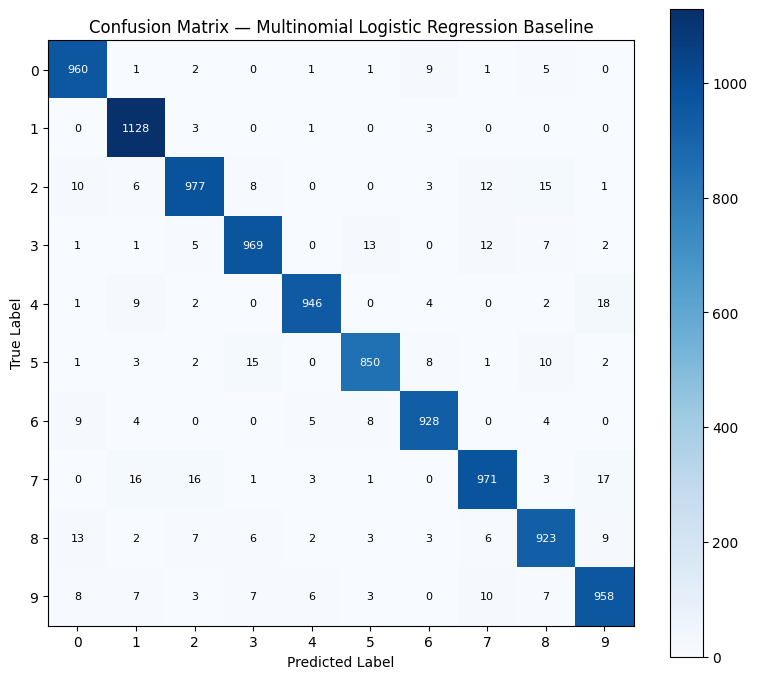


Baseline results saved successfully!


In [6]:
from evaluation.multiclass_metrics import evaluate_multiclass
import json
import numpy as np

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
results_baseline = evaluate_multiclass(
    y_test,
    y_pred,
    model_name="Multinomial Logistic Regression Baseline"
)

# Convert NumPy objects to JSON-serializable format
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64, np.uint8)):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    else:
        return obj

results_baseline_serializable = convert_to_serializable(results_baseline)

# Save results
with open("results/phase2/multinomial_logreg_baseline.json", "w") as f:
    json.dump(results_baseline_serializable, f, indent=4)

print("\nBaseline results saved successfully!")

# Feature Comparison Experiment


Feature Method: FLATTEN
 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 784)  y_tr   : (48000,)
   X_val  : (12000, 784)  y_val  : (12000,)
   X_test : (10000, 784)  y_test : (10

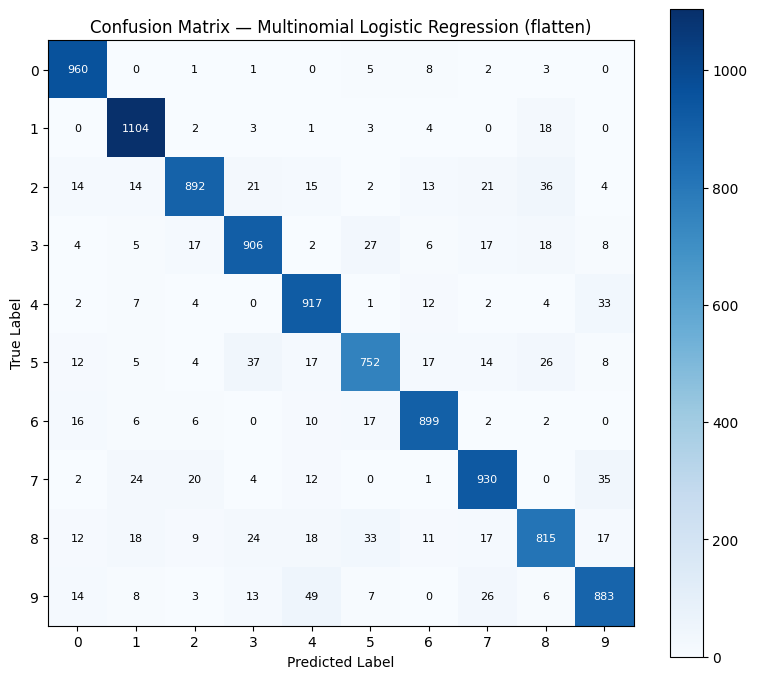


Feature Method: PCA
 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 1.0000

 Preprocessing 

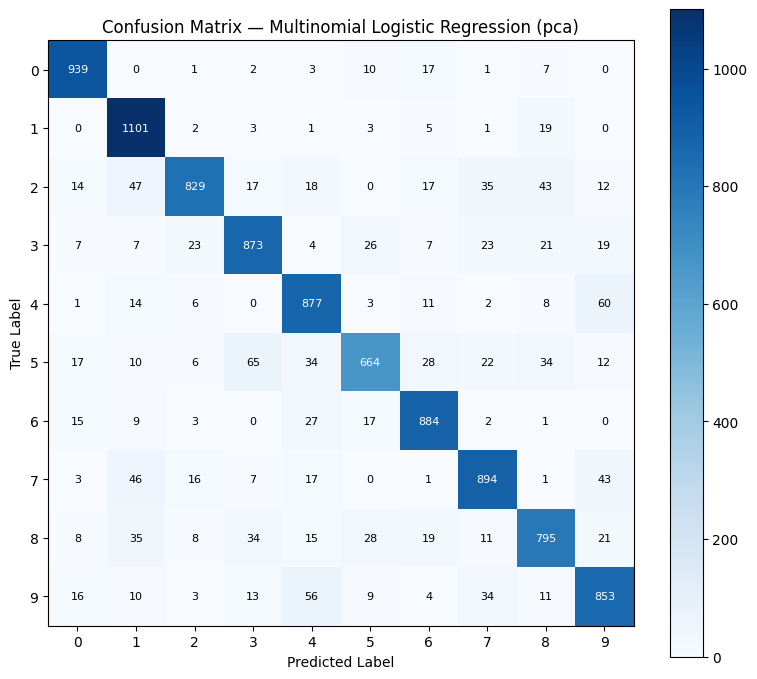


Feature Method: HOG
 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 0.9943

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 441)  y_t

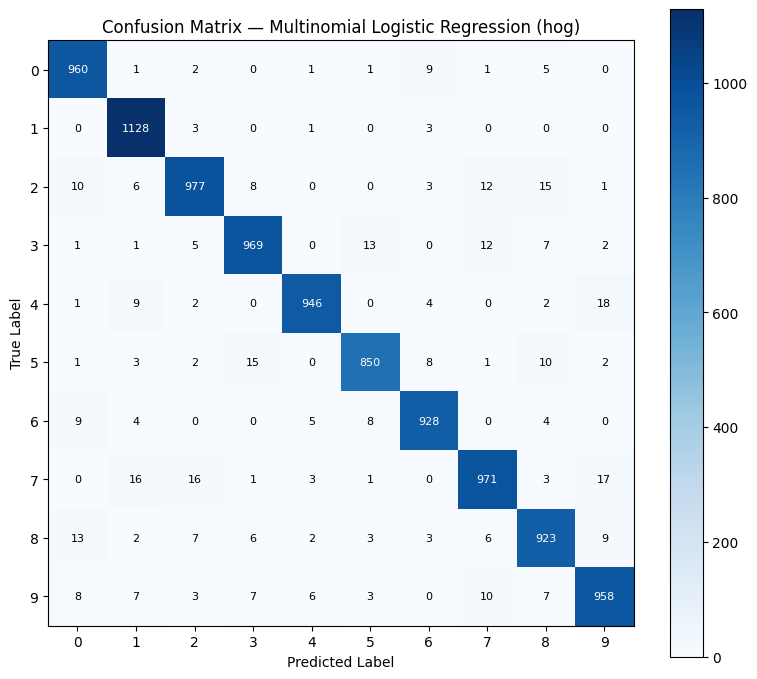


Feature comparison results saved successfully!


In [7]:
from preprocessing.preprocess import preprocess
from models.multinomial_logistic_regression import MultinomialLogisticRegression
from evaluation.multiclass_metrics import evaluate_multiclass

import json
import numpy as np

feature_methods = ["flatten", "pca", "hog"]

results_features = {}

for feature in feature_methods:

    print("\n" + "="*70)
    print(f"Feature Method: {feature.upper()}")
    print("="*70)

    # Load data
    X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
        feature_method=feature,
        binary=False
    )

    # Initialize model
    model = MultinomialLogisticRegression(
        lr=0.01,
        epochs=1000,
        lambda_=0.01
    )

    # Train
    model.fit(X_tr, y_tr)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    results = evaluate_multiclass(
        y_test,
        y_pred,
        model_name=f"Multinomial Logistic Regression ({feature})"
    )

    results_features[feature] = results


# Convert NumPy objects to JSON serializable
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64, np.uint8)):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    else:
        return obj


results_features_serializable = convert_to_serializable(results_features)

# Save results
with open("results/phase2/multinomial_logreg_feature_comparison.json", "w") as f:
    json.dump(results_features_serializable, f, indent=4)

print("\nFeature comparison results saved successfully!")

# Hyperparameter Tuning with Cross-Validation

In [8]:
from importlib import reload
import models.multinomial_logistic_regression as mlr

reload(mlr)

from models.multinomial_logistic_regression import MultinomialLogisticRegression

print("Updated model loaded successfully!")

Updated model loaded successfully!


In [9]:
help(MultinomialLogisticRegression.fit)

Help on function fit in module models.multinomial_logistic_regression:

fit(self, X, y, X_val=None, y_val=None)



 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 0.9943

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 441)  y_tr   : (48000,)
   X_v

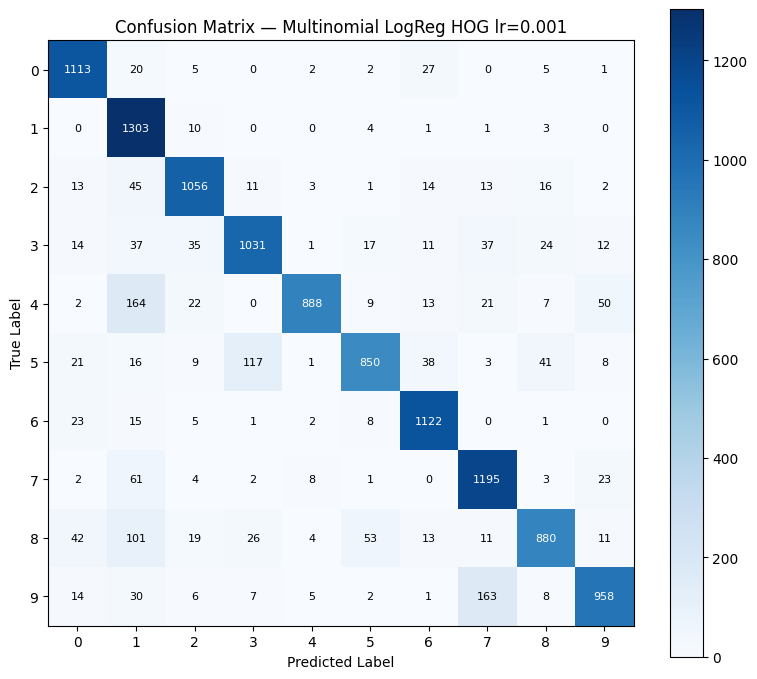


Learning Rate: 0.01
Multiclass Classification Report — Multinomial LogReg HOG lr=0.01
Accuracy           : 0.9292 (92.92%)
Macro Precision    : 0.9310
Macro Recall       : 0.9283
Macro F1-score     : 0.9291
Weighted Precision : 0.9303
Weighted Recall    : 0.9292
Weighted F1-score  : 0.9291
----------------------------------------------------------------------
Class 0: Precision=0.9437 | Recall=0.9557 | F1=0.9497 | Support=1175
Class 1: Precision=0.8736 | Recall=0.9879 | F1=0.9272 | Support=1322
Class 2: Precision=0.9370 | Recall=0.9114 | F1=0.9240 | Support=1174
Class 3: Precision=0.9383 | Recall=0.9106 | F1=0.9242 | Support=1219
Class 4: Precision=0.9606 | Recall=0.9133 | F1=0.9364 | Support=1176
Class 5: Precision=0.9559 | Recall=0.9022 | F1=0.9282 | Support=1104
Class 6: Precision=0.9503 | Recall=0.9575 | F1=0.9539 | Support=1177
Class 7: Precision=0.9375 | Recall=0.9246 | F1=0.9310 | Support=1299
Class 8: Precision=0.9036 | Recall=0.8810 | F1=0.8922 | Support=1160
Class 9: Precisi

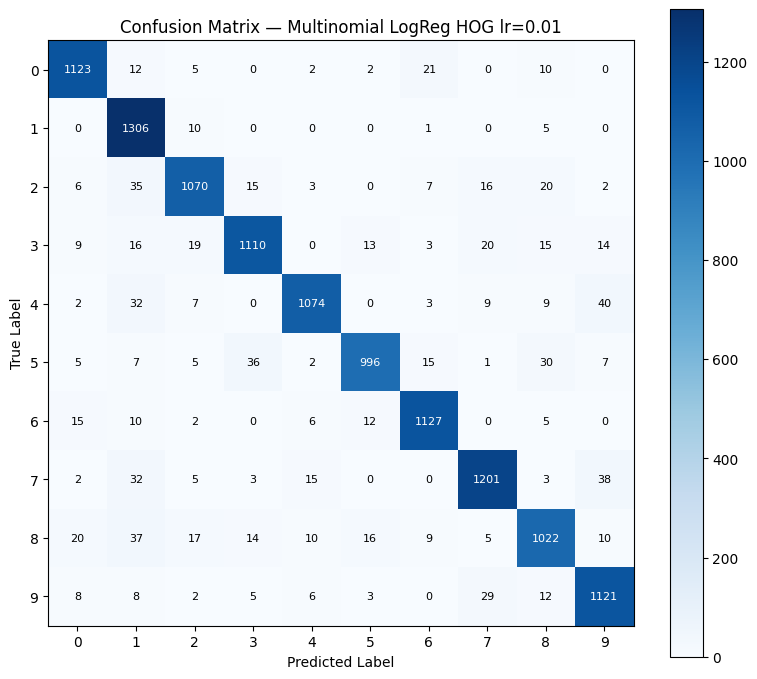


Learning Rate: 0.05
Multiclass Classification Report — Multinomial LogReg HOG lr=0.05
Accuracy           : 0.9577 (95.78%)
Macro Precision    : 0.9582
Macro Recall       : 0.9573
Macro F1-score     : 0.9576
Weighted Precision : 0.9579
Weighted Recall    : 0.9577
Weighted F1-score  : 0.9577
----------------------------------------------------------------------
Class 0: Precision=0.9702 | Recall=0.9694 | F1=0.9698 | Support=1175
Class 1: Precision=0.9391 | Recall=0.9909 | F1=0.9643 | Support=1322
Class 2: Precision=0.9530 | Recall=0.9506 | F1=0.9518 | Support=1174
Class 3: Precision=0.9729 | Recall=0.9434 | F1=0.9579 | Support=1219
Class 4: Precision=0.9698 | Recall=0.9549 | F1=0.9623 | Support=1176
Class 5: Precision=0.9660 | Recall=0.9529 | F1=0.9594 | Support=1104
Class 6: Precision=0.9670 | Recall=0.9711 | F1=0.9691 | Support=1177
Class 7: Precision=0.9547 | Recall=0.9577 | F1=0.9562 | Support=1299
Class 8: Precision=0.9414 | Recall=0.9276 | F1=0.9344 | Support=1160
Class 9: Precisi

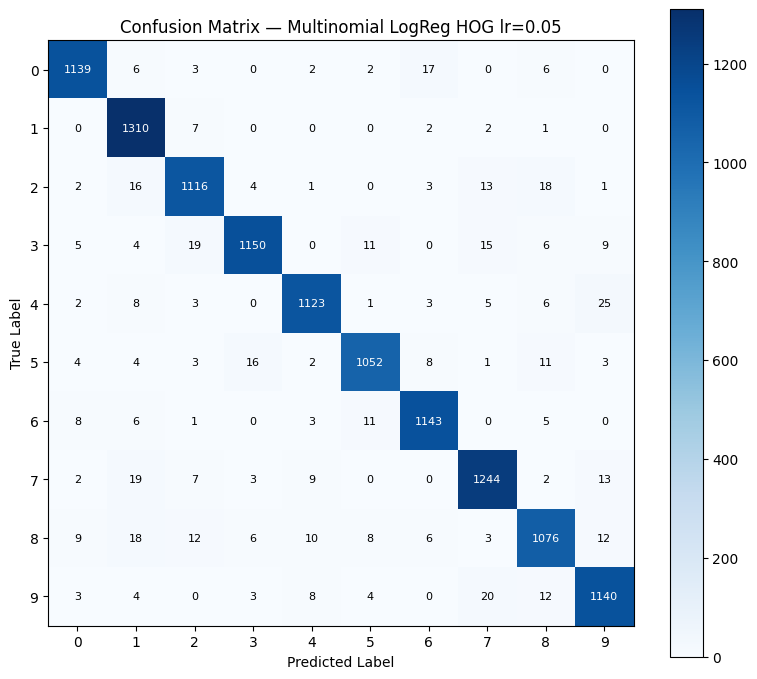


Learning Rate: 0.1
Multiclass Classification Report — Multinomial LogReg HOG lr=0.1
Accuracy           : 0.9636 (96.36%)
Macro Precision    : 0.9638
Macro Recall       : 0.9632
Macro F1-score     : 0.9634
Weighted Precision : 0.9637
Weighted Recall    : 0.9636
Weighted F1-score  : 0.9636
----------------------------------------------------------------------
Class 0: Precision=0.9703 | Recall=0.9745 | F1=0.9724 | Support=1175
Class 1: Precision=0.9548 | Recall=0.9902 | F1=0.9722 | Support=1322
Class 2: Precision=0.9566 | Recall=0.9574 | F1=0.9570 | Support=1174
Class 3: Precision=0.9773 | Recall=0.9524 | F1=0.9647 | Support=1219
Class 4: Precision=0.9741 | Recall=0.9592 | F1=0.9666 | Support=1176
Class 5: Precision=0.9698 | Recall=0.9592 | F1=0.9645 | Support=1104
Class 6: Precision=0.9688 | Recall=0.9745 | F1=0.9716 | Support=1177
Class 7: Precision=0.9603 | Recall=0.9677 | F1=0.9640 | Support=1299
Class 8: Precision=0.9486 | Recall=0.9388 | F1=0.9437 | Support=1160
Class 9: Precision

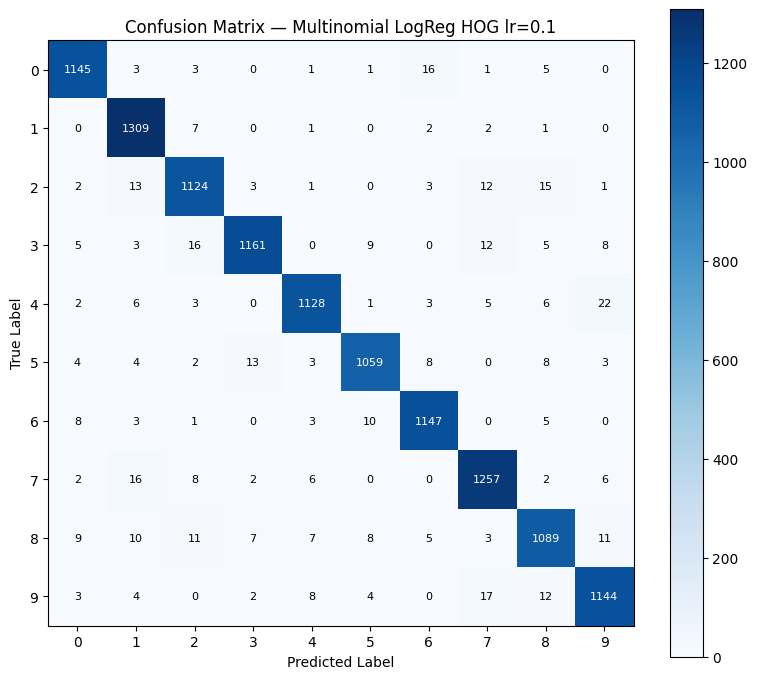

Learning rate tuning saved successfully!


In [12]:
from preprocessing.preprocess import preprocess
from models.multinomial_logistic_regression import MultinomialLogisticRegression
from evaluation.multiclass_metrics import evaluate_multiclass
import json
import numpy as np

X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='hog',
    binary=False
)

learning_rates = [0.001, 0.01, 0.05, 0.1]

results_lr = {}

for lr in learning_rates:

    print("\n" + "="*70)
    print(f"Learning Rate: {lr}")
    print("="*70)

    model = MultinomialLogisticRegression(
        lr=lr,
        epochs=200,
        lambda_=0.01
    )

    model.fit(X_tr, y_tr, X_val=X_val, y_val=y_val)

    y_val_pred = model.predict(X_val)

    results = evaluate_multiclass(
        y_val,
        y_val_pred,
        model_name=f"Multinomial LogReg HOG lr={lr}"
    )

    results_lr[f"lr_{lr}"] = {
        "metrics": results,
        "final_train_acc": model.train_acc_history[-1],
        "final_val_acc": model.val_acc_history[-1],
        "final_train_loss": model.loss_history[-1],
        "final_val_loss": model.val_loss_history[-1]
    }


def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64, np.uint8)):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    return obj


with open("results/phase2/multinomial_logreg_lr_tuning.json", "w") as f:
    json.dump(convert_to_serializable(results_lr), f, indent=4)

print("Learning rate tuning saved successfully!")

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 0.9943

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 441)  y_tr   : (48000,)
   X_v

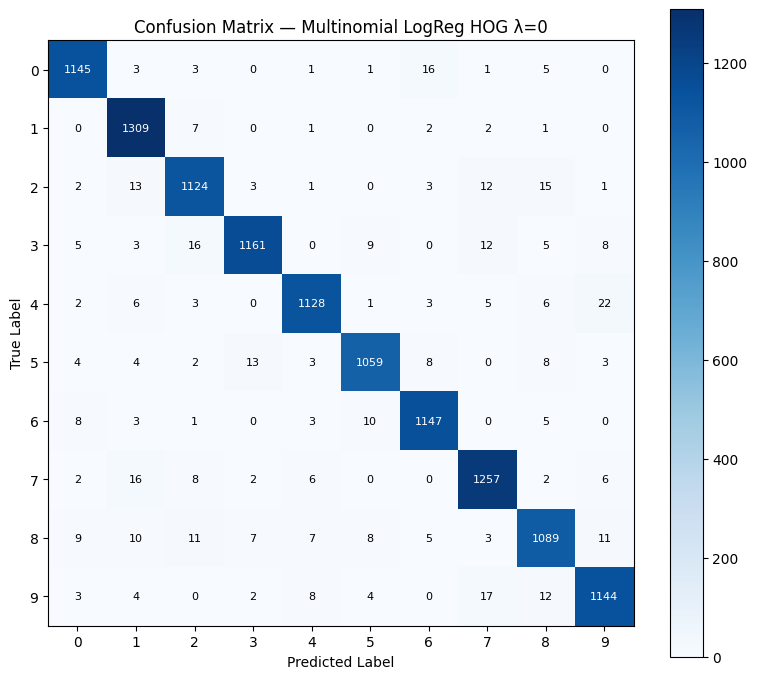


Lambda: 0.01
Multiclass Classification Report — Multinomial LogReg HOG λ=0.01
Accuracy           : 0.9636 (96.36%)
Macro Precision    : 0.9638
Macro Recall       : 0.9632
Macro F1-score     : 0.9634
Weighted Precision : 0.9637
Weighted Recall    : 0.9636
Weighted F1-score  : 0.9636
----------------------------------------------------------------------
Class 0: Precision=0.9703 | Recall=0.9745 | F1=0.9724 | Support=1175
Class 1: Precision=0.9548 | Recall=0.9902 | F1=0.9722 | Support=1322
Class 2: Precision=0.9566 | Recall=0.9574 | F1=0.9570 | Support=1174
Class 3: Precision=0.9773 | Recall=0.9524 | F1=0.9647 | Support=1219
Class 4: Precision=0.9741 | Recall=0.9592 | F1=0.9666 | Support=1176
Class 5: Precision=0.9698 | Recall=0.9592 | F1=0.9645 | Support=1104
Class 6: Precision=0.9688 | Recall=0.9745 | F1=0.9716 | Support=1177
Class 7: Precision=0.9603 | Recall=0.9677 | F1=0.9640 | Support=1299
Class 8: Precision=0.9486 | Recall=0.9388 | F1=0.9437 | Support=1160
Class 9: Precision=0.957

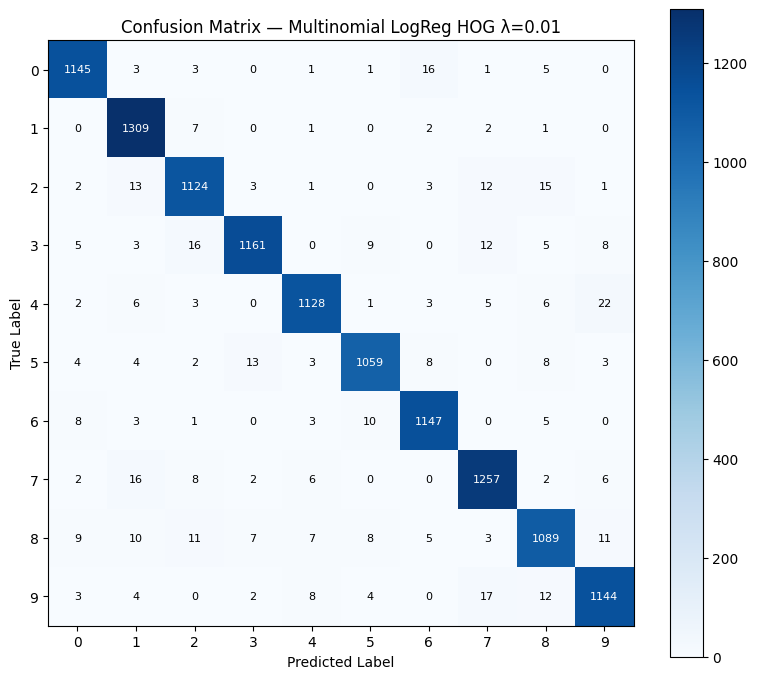


Lambda: 0.1
Multiclass Classification Report — Multinomial LogReg HOG λ=0.1
Accuracy           : 0.9636 (96.36%)
Macro Precision    : 0.9638
Macro Recall       : 0.9632
Macro F1-score     : 0.9634
Weighted Precision : 0.9637
Weighted Recall    : 0.9636
Weighted F1-score  : 0.9636
----------------------------------------------------------------------
Class 0: Precision=0.9703 | Recall=0.9745 | F1=0.9724 | Support=1175
Class 1: Precision=0.9548 | Recall=0.9902 | F1=0.9722 | Support=1322
Class 2: Precision=0.9566 | Recall=0.9574 | F1=0.9570 | Support=1174
Class 3: Precision=0.9773 | Recall=0.9524 | F1=0.9647 | Support=1219
Class 4: Precision=0.9741 | Recall=0.9592 | F1=0.9666 | Support=1176
Class 5: Precision=0.9698 | Recall=0.9592 | F1=0.9645 | Support=1104
Class 6: Precision=0.9688 | Recall=0.9745 | F1=0.9716 | Support=1177
Class 7: Precision=0.9603 | Recall=0.9677 | F1=0.9640 | Support=1299
Class 8: Precision=0.9486 | Recall=0.9388 | F1=0.9437 | Support=1160
Class 9: Precision=0.9573 

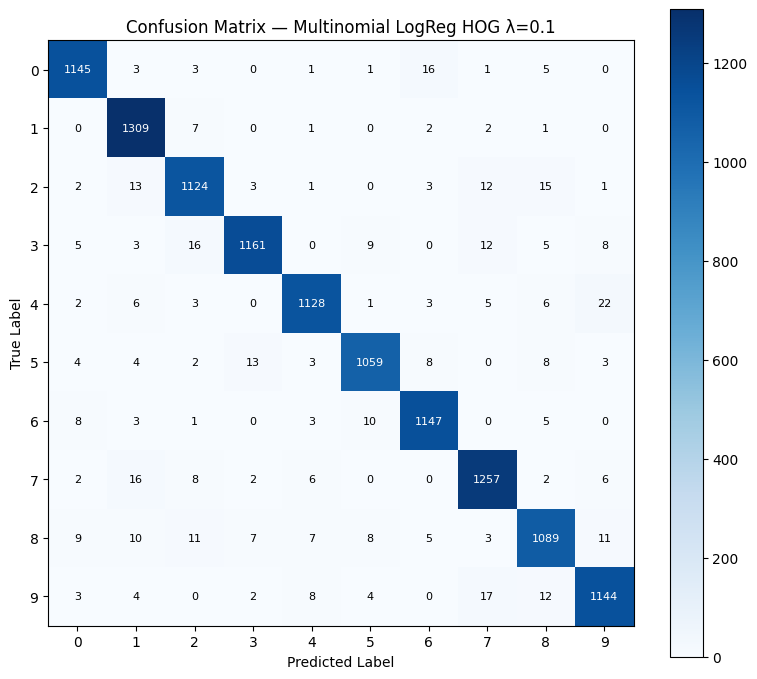


Lambda: 1
Multiclass Classification Report — Multinomial LogReg HOG λ=1
Accuracy           : 0.9636 (96.36%)
Macro Precision    : 0.9638
Macro Recall       : 0.9632
Macro F1-score     : 0.9634
Weighted Precision : 0.9637
Weighted Recall    : 0.9636
Weighted F1-score  : 0.9636
----------------------------------------------------------------------
Class 0: Precision=0.9703 | Recall=0.9745 | F1=0.9724 | Support=1175
Class 1: Precision=0.9548 | Recall=0.9902 | F1=0.9722 | Support=1322
Class 2: Precision=0.9566 | Recall=0.9574 | F1=0.9570 | Support=1174
Class 3: Precision=0.9773 | Recall=0.9524 | F1=0.9647 | Support=1219
Class 4: Precision=0.9741 | Recall=0.9592 | F1=0.9666 | Support=1176
Class 5: Precision=0.9698 | Recall=0.9592 | F1=0.9645 | Support=1104
Class 6: Precision=0.9688 | Recall=0.9745 | F1=0.9716 | Support=1177
Class 7: Precision=0.9603 | Recall=0.9677 | F1=0.9640 | Support=1299
Class 8: Precision=0.9486 | Recall=0.9388 | F1=0.9437 | Support=1160
Class 9: Precision=0.9573 | Re

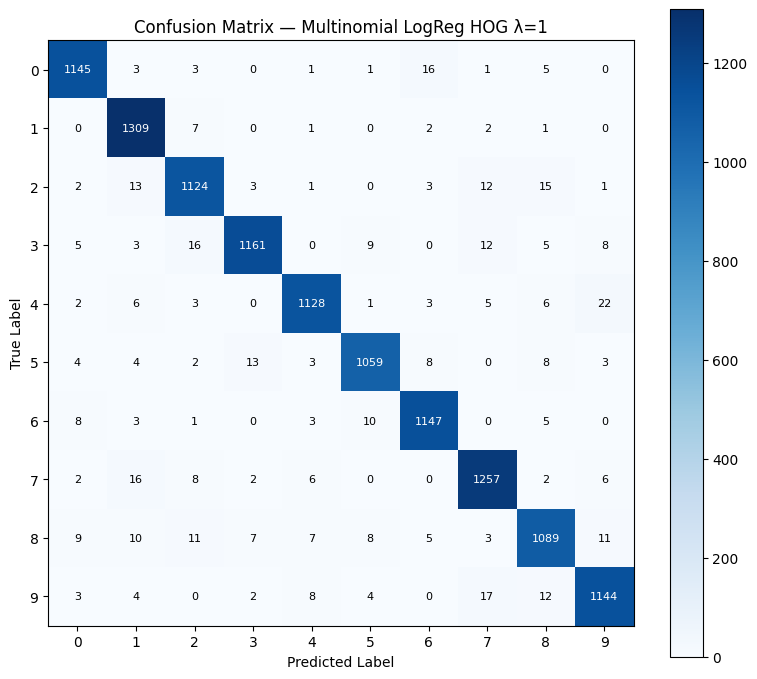


Lambda: 10
Multiclass Classification Report — Multinomial LogReg HOG λ=10
Accuracy           : 0.9636 (96.36%)
Macro Precision    : 0.9638
Macro Recall       : 0.9632
Macro F1-score     : 0.9634
Weighted Precision : 0.9637
Weighted Recall    : 0.9636
Weighted F1-score  : 0.9636
----------------------------------------------------------------------
Class 0: Precision=0.9703 | Recall=0.9745 | F1=0.9724 | Support=1175
Class 1: Precision=0.9548 | Recall=0.9902 | F1=0.9722 | Support=1322
Class 2: Precision=0.9566 | Recall=0.9574 | F1=0.9570 | Support=1174
Class 3: Precision=0.9773 | Recall=0.9524 | F1=0.9647 | Support=1219
Class 4: Precision=0.9741 | Recall=0.9592 | F1=0.9666 | Support=1176
Class 5: Precision=0.9698 | Recall=0.9592 | F1=0.9645 | Support=1104
Class 6: Precision=0.9688 | Recall=0.9745 | F1=0.9716 | Support=1177
Class 7: Precision=0.9603 | Recall=0.9677 | F1=0.9640 | Support=1299
Class 8: Precision=0.9486 | Recall=0.9388 | F1=0.9437 | Support=1160
Class 9: Precision=0.9573 | 

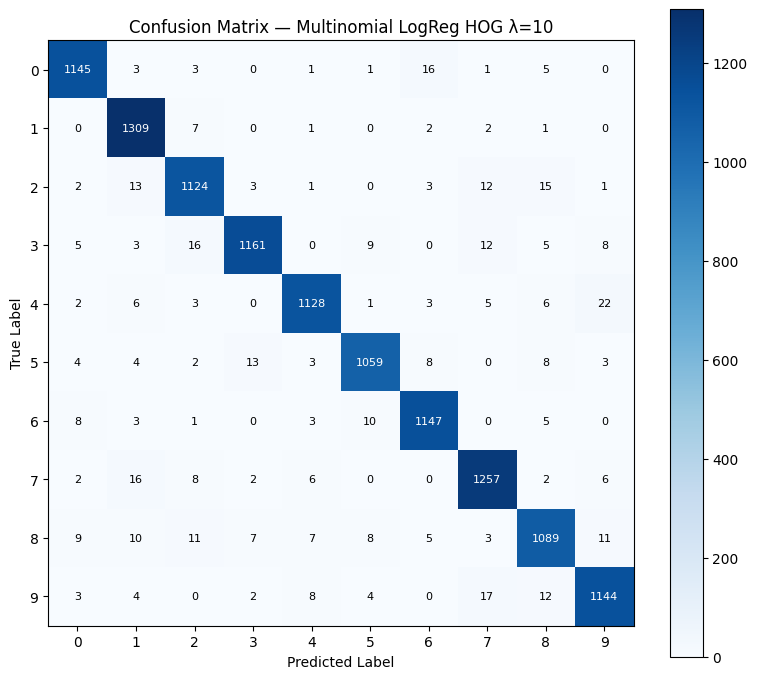


Lambda tuning saved successfully!


In [13]:
from preprocessing.preprocess import preprocess
from models.multinomial_logistic_regression import MultinomialLogisticRegression
from evaluation.multiclass_metrics import evaluate_multiclass

import json
import numpy as np

# Load HOG features
X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='hog',
    binary=False
)

lambda_values = [0, 0.01, 0.1, 1, 10]

results_lambda = {}

for lam in lambda_values:

    print("\n" + "="*70)
    print(f"Lambda: {lam}")
    print("="*70)

    model = MultinomialLogisticRegression(
        lr=0.1,              # best LR from tuning
        epochs=200,
        lambda_=lam
    )

    model.fit(
        X_tr,
        y_tr,
        X_val=X_val,
        y_val=y_val
    )

    y_val_pred = model.predict(X_val)

    results = evaluate_multiclass(
        y_val,
        y_val_pred,
        model_name=f"Multinomial LogReg HOG λ={lam}"
    )

    results_lambda[f"lambda_{lam}"] = {
        "metrics": results,
        "final_train_acc": model.train_acc_history[-1],
        "final_val_acc": model.val_acc_history[-1],
        "final_train_loss": model.loss_history[-1],
        "final_val_loss": model.val_loss_history[-1]
    }


def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64, np.uint8)):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    return obj


with open("results/phase2/multinomial_logreg_lambda_tuning.json", "w") as f:
    json.dump(convert_to_serializable(results_lambda), f, indent=4)

print("\nLambda tuning saved successfully!")

# Learning Curves + Overfitting / Underfitting Diagnosis

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Multi-class

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Multi-class mode — labels kept as original (0-9)

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : -0.0000
   Training std  (should be ~1) : 0.9943

 Preprocessing Pipeline Complete!
   X_tr   : (48000, 441)  y_tr   : (48000,)
   X_v

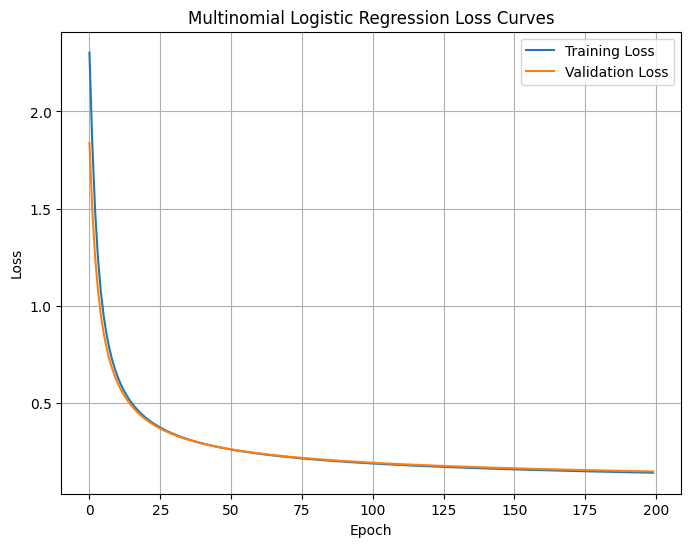

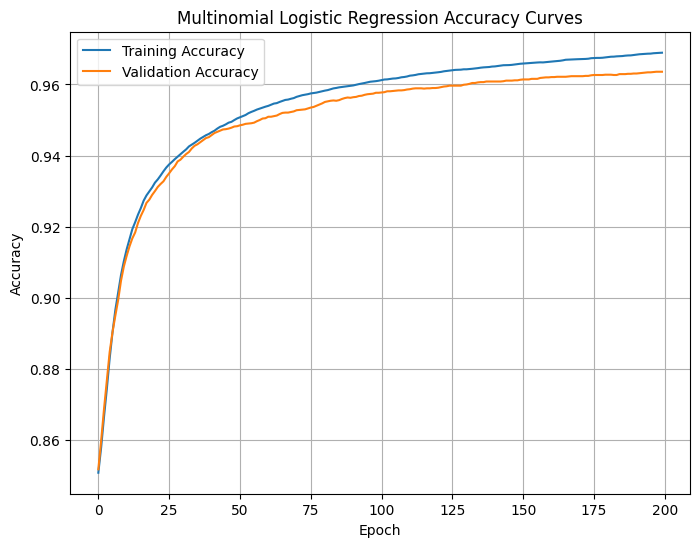

Learning curves saved successfully!


In [14]:
from preprocessing.preprocess import preprocess
from models.multinomial_logistic_regression import MultinomialLogisticRegression
import matplotlib.pyplot as plt

# Load best feature set
X_tr, X_val, X_test, y_tr, y_val, y_test = preprocess(
    feature_method='hog',
    binary=False
)

# Best model
best_model = MultinomialLogisticRegression(
    lr=0.1,
    epochs=200,
    lambda_=0.01
)

best_model.fit(
    X_tr,
    y_tr,
    X_val=X_val,
    y_val=y_val
)

# Plot training/validation loss
plt.figure(figsize=(8, 6))
plt.plot(best_model.loss_history, label="Training Loss")
plt.plot(best_model.val_loss_history, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multinomial Logistic Regression Loss Curves")
plt.legend()
plt.grid(True)
plt.savefig("results/phase2/multinomial_logreg_loss_curves.png")
plt.show()

# Plot training/validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(best_model.train_acc_history, label="Training Accuracy")
plt.plot(best_model.val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Multinomial Logistic Regression Accuracy Curves")
plt.legend()
plt.grid(True)
plt.savefig("results/phase2/multinomial_logreg_accuracy_curves.png")
plt.show()

print("Learning curves saved successfully!")

Multiclass Classification Report — Final Multinomial Logistic Regression
Accuracy           : 0.9672 (96.72%)
Macro Precision    : 0.9673
Macro Recall       : 0.9669
Macro F1-score     : 0.9670
Weighted Precision : 0.9672
Weighted Recall    : 0.9672
Weighted F1-score  : 0.9672
----------------------------------------------------------------------
Class 0: Precision=0.9601 | Recall=0.9827 | F1=0.9713 | Support=980
Class 1: Precision=0.9683 | Recall=0.9947 | F1=0.9813 | Support=1135
Class 2: Precision=0.9668 | Recall=0.9583 | F1=0.9625 | Support=1032
Class 3: Precision=0.9663 | Recall=0.9653 | F1=0.9658 | Support=1010
Class 4: Precision=0.9815 | Recall=0.9715 | F1=0.9765 | Support=982
Class 5: Precision=0.9728 | Recall=0.9608 | F1=0.9667 | Support=892
Class 6: Precision=0.9728 | Recall=0.9708 | F1=0.9718 | Support=958
Class 7: Precision=0.9628 | Recall=0.9572 | F1=0.9600 | Support=1028
Class 8: Precision=0.9549 | Recall=0.9569 | F1=0.9559 | Support=974
Class 9: Precision=0.9667 | Recall=

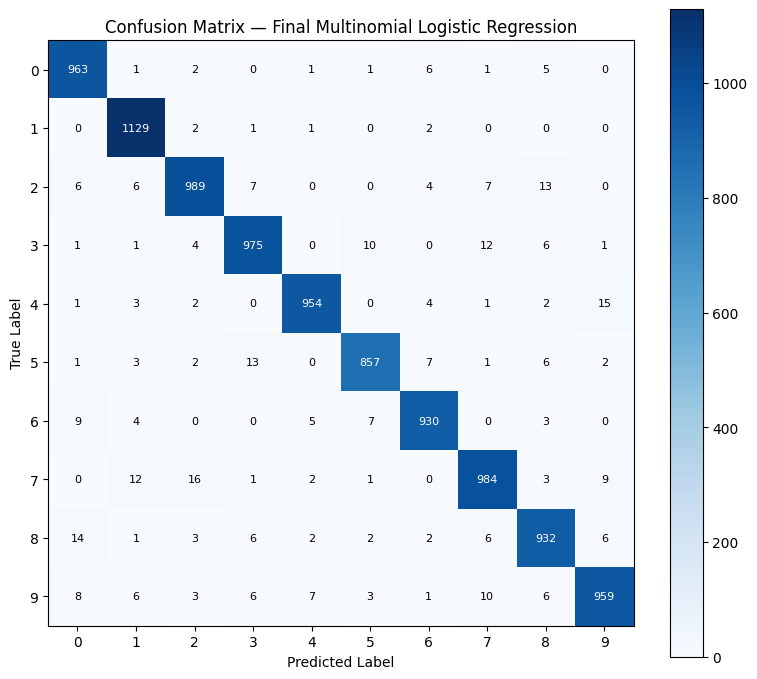

Final test results saved successfully!


In [15]:
from evaluation.multiclass_metrics import evaluate_multiclass
import json
import numpy as np

# Final prediction on TEST set
y_test_pred = best_model.predict(X_test)

# Final evaluation
final_results = evaluate_multiclass(
    y_test,
    y_test_pred,
    model_name="Final Multinomial Logistic Regression"
)

# JSON serializer
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64, np.uint8)):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    return obj

with open("results/phase2/multinomial_logreg_final_test_results.json", "w") as f:
    json.dump(convert_to_serializable(final_results), f, indent=4)

print("Final test results saved successfully!")

In [16]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
  (commit or discard the untracked or modified content in submodules)
	modified:   MNIST-ML-ImageClassifiers (new commits, untracked content)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/multinomial_logistic_regression.py
	results/phase2/multinomial_logreg_accuracy_curves.png
	results/phase2/multinomial_logreg_baseline.json
	results/phase2/multinomial_logreg_feature_comparison.json
	results/phase2/multinomial_logreg_final_test_results.json
	results/phase2/multinomial_logreg_lambda_tuning.json
	results/phase2/multinomial_logreg_loss_curves.png
	results/phase2/multinomial_logreg_lr_tuning.json

no changes added to commit (use "git add" and/or "git commit -a")


In [17]:
!git branch

* main
  multinomialLR


In [18]:
!git checkout multinomialLR

M	MNIST-ML-ImageClassifiers
Switched to branch 'multinomialLR'


In [19]:
!git status

On branch multinomialLR
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
  (commit or discard the untracked or modified content in submodules)
	modified:   MNIST-ML-ImageClassifiers (new commits, untracked content)

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/multinomial_logistic_regression.py
	results/phase2/multinomial_logreg_accuracy_curves.png
	results/phase2/multinomial_logreg_baseline.json
	results/phase2/multinomial_logreg_feature_comparison.json
	results/phase2/multinomial_logreg_final_test_results.json
	results/phase2/multinomial_logreg_lambda_tuning.json
	results/phase2/multinomial_logreg_loss_curves.png
	results/phase2/multinomial_logreg_lr_tuning.json

no changes added to commit (use "git add" and/or "git commit -a")


In [20]:
!ls

evaluation		   models     preprocessing  report
MNIST-ML-ImageClassifiers  notebooks  README.md      results


In [21]:
!rm -rf MNIST-ML-ImageClassifiers

In [22]:
!git status

On branch multinomialLR
Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    MNIST-ML-ImageClassifiers

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/multinomial_logistic_regression.py
	results/phase2/multinomial_logreg_accuracy_curves.png
	results/phase2/multinomial_logreg_baseline.json
	results/phase2/multinomial_logreg_feature_comparison.json
	results/phase2/multinomial_logreg_final_test_results.json
	results/phase2/multinomial_logreg_lambda_tuning.json
	results/phase2/multinomial_logreg_loss_curves.png
	results/phase2/multinomial_logreg_lr_tuning.json

no changes added to commit (use "git add" and/or "git commit -a")


In [23]:
!git restore MNIST-ML-ImageClassifiers

In [24]:
!git status

On branch multinomialLR
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/multinomial_logistic_regression.py
	results/phase2/multinomial_logreg_accuracy_curves.png
	results/phase2/multinomial_logreg_baseline.json
	results/phase2/multinomial_logreg_feature_comparison.json
	results/phase2/multinomial_logreg_final_test_results.json
	results/phase2/multinomial_logreg_lambda_tuning.json
	results/phase2/multinomial_logreg_loss_curves.png
	results/phase2/multinomial_logreg_lr_tuning.json

nothing added to commit but untracked files present (use "git add" to track)


In [25]:
!git add models/multinomial_logistic_regression.py
!git add results/phase2/multinomial_logreg_accuracy_curves.png
!git add results/phase2/multinomial_logreg_baseline.json
!git add results/phase2/multinomial_logreg_feature_comparison.json
!git add results/phase2/multinomial_logreg_final_test_results.json
!git add results/phase2/multinomial_logreg_lambda_tuning.json
!git add results/phase2/multinomial_logreg_loss_curves.png
!git add results/phase2/multinomial_logreg_lr_tuning.json

In [26]:
!git status

On branch multinomialLR
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   models/multinomial_logistic_regression.py
	new file:   results/phase2/multinomial_logreg_accuracy_curves.png
	new file:   results/phase2/multinomial_logreg_baseline.json
	new file:   results/phase2/multinomial_logreg_feature_comparison.json
	new file:   results/phase2/multinomial_logreg_final_test_results.json
	new file:   results/phase2/multinomial_logreg_lambda_tuning.json
	new file:   results/phase2/multinomial_logreg_loss_curves.png
	new file:   results/phase2/multinomial_logreg_lr_tuning.json



In [27]:
!git commit -m "Add Phase 2 multinomial logistic regression with tuning and learning curve analysis"

[multinomialLR 008745d] Add Phase 2 multinomial logistic regression with tuning and learning curve analysis
 8 files changed, 837 insertions(+)
 create mode 100644 models/multinomial_logistic_regression.py
 create mode 100644 results/phase2/multinomial_logreg_accuracy_curves.png
 create mode 100644 results/phase2/multinomial_logreg_baseline.json
 create mode 100644 results/phase2/multinomial_logreg_feature_comparison.json
 create mode 100644 results/phase2/multinomial_logreg_final_test_results.json
 create mode 100644 results/phase2/multinomial_logreg_lambda_tuning.json
 create mode 100644 results/phase2/multinomial_logreg_loss_curves.png
 create mode 100644 results/phase2/multinomial_logreg_lr_tuning.json


In [28]:
!git push origin multinomialLR

fatal: could not read Password for 'https://YOUR_PERSONAL_ACCESS_TOKEN@github.com': No such device or address


In [29]:
!git remote set-url origin https://loaymahmoud10:@github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers.git

In [30]:
!git push origin multinomialLR

Enumerating objects: 17, done.
Counting objects: 100% (17/17), done.
Delta compression using up to 2 threads
Compressing objects: 100% (13/13), done.
Writing objects: 100% (13/13), 69.88 KiB | 3.88 MiB/s, done.
Total 13 (delta 6), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (6/6), completed with 4 local objects.
remote: 
remote: Create a pull request for 'multinomialLR' on GitHub by visiting:
remote:      https://github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers/pull/new/multinomialLR
remote: 
To https://github.com/AbdelrahmanAdel-1/MNIST-ML-ImageClassifiers.git
 * [new branch]      multinomialLR -> multinomialLR
